In [1]:
import os

**Dataset Link**
https://www.kaggle.com/datasets/awaiskaggler/insurance-csv

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

In [3]:
import sklearn
print(sklearn.__version__)

1.2.2


In [4]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression

In [5]:
df = pd.read_csv("/kaggle/input/insurance-csv/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [6]:
# Check for the null values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [7]:
# Check the datatypes for encoding
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
expenses    float64
dtype: object

In [8]:
# Copy the contents of the dataset
df_original = df.copy()
df_copy = df.copy()
print("Dataset copied successfully!")

Dataset copied successfully!


In [9]:
# Encoding the categorical values
import pickle

encoders = {}
for col in df_copy.columns:
    if df_copy[col].dtype == 'object':
        encoder = LabelEncoder()
        df_copy[col] = encoder.fit_transform(df_copy[col])
        encoders[col] = encoder

with open("adaboost_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("AdaBoost encoders loaded successfully!")

AdaBoost encoders loaded successfully!


In [10]:
# Check the datatypes after encoding
df_copy.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
expenses    float64
dtype: object

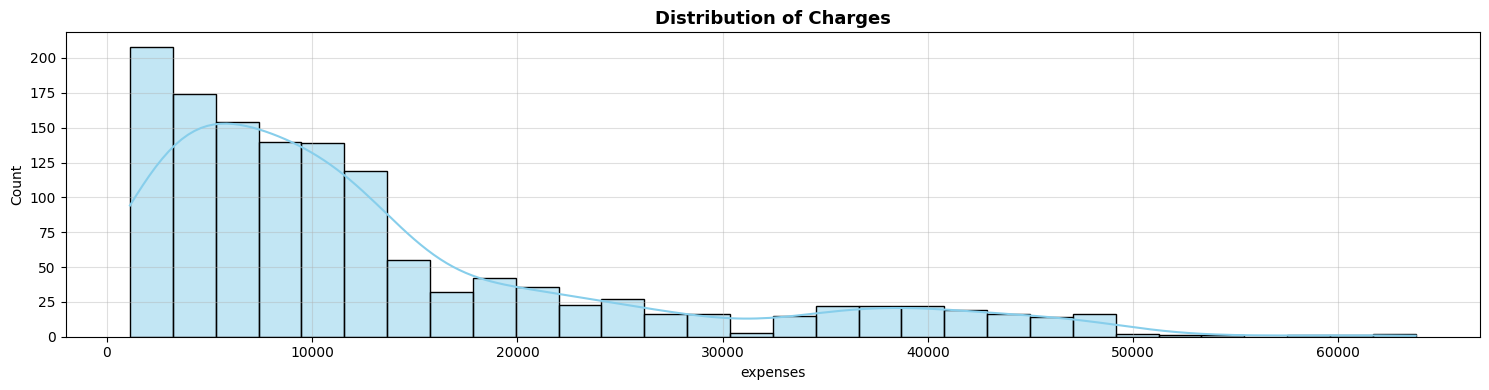

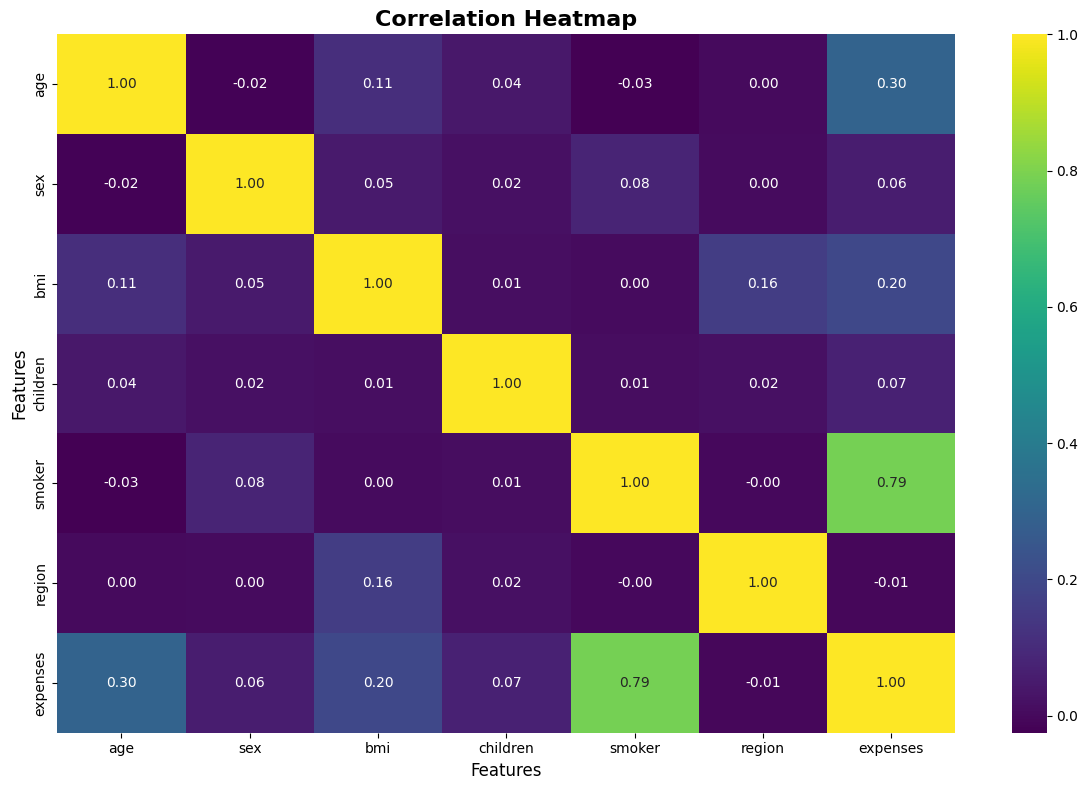

In [11]:
# Distribution Graph of Charges
plt.figure(figsize=(15, 4))
sns.histplot(df_copy['expenses'], kde=True, color='skyblue')
plt.title("Distribution of Charges", fontsize=13, fontweight='bold')
plt.xlabel("expenses")
plt.ylabel("Count")
plt.grid(True, alpha=0.4)

# Showing the distribution graphs
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_copy.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# Extract the independent and dependent variables
X = df_copy.drop(columns=['expenses'])
y = df_copy['expenses']

# Split into Train and Test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Scale the dataset and save the scalers
import pickle

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler using pickle
with open("adaboost_scalers.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("AdaBoost scalers dumped successfully!")

AdaBoost scalers dumped successfully!


In [14]:
import optuna
from sklearn.ensemble import AdaBoostRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50,500, step=50)
    learning_rate = trial.suggest_float('learning_rate', 0.0001, 0.1, log=True)
    loss = trial.suggest_categorical('loss', ['square', 'linear', 'exponential'])
    random_state = trial.suggest_int('random_state', 1,100)

    # Define AdaBoost model
    model = AdaBoostRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        loss=loss,
        random_state=random_state,
    )

    # Pipeline with scaling
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # Evaluate using 5-fold CV with R² metric
    score = cross_val_score(pipeline, X_train_scaled, y_train, cv=5, scoring='r2').mean()

    return score

In [15]:
import joblib

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Print results
print("Best Hyperparameters:", study.best_params)
print("Best R² Score:", study.best_value)

# Rebuild final model
best_model = study.best_params

adaboost_model = AdaBoostRegressor(
    n_estimators=best_model['n_estimators'],
    learning_rate=best_model['learning_rate'],
    loss=best_model['loss'],
    random_state=best_model['random_state']
)

joblib.dump(adaboost_model, "insurance_charges.pkl")

# Fit and predict the model
adaboost_model.fit(X_train_scaled, y_train)
y_pred = adaboost_model.predict(X_test_scaled)

[I 2026-01-02 13:07:03,235] A new study created in memory with name: no-name-c272dd87-2746-4b98-80db-51aafae7ef62


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-01-02 13:07:04,316] Trial 0 finished with value: 0.8394791886475277 and parameters: {'n_estimators': 100, 'learning_rate': 0.000627319909114107, 'loss': 'linear', 'random_state': 65}. Best is trial 0 with value: 0.8394791886475277.
[I 2026-01-02 13:07:05,899] Trial 1 finished with value: 0.8408466546602529 and parameters: {'n_estimators': 150, 'learning_rate': 0.00029296535949630475, 'loss': 'linear', 'random_state': 90}. Best is trial 1 with value: 0.8408466546602529.
[I 2026-01-02 13:07:08,514] Trial 2 finished with value: 0.8408139949447341 and parameters: {'n_estimators': 250, 'learning_rate': 0.0003002218742479814, 'loss': 'square', 'random_state': 34}. Best is trial 1 with value: 0.8408466546602529.
[I 2026-01-02 13:07:12,561] Trial 3 finished with value: 0.6951171814223711 and parameters: {'n_estimators': 400, 'learning_rate': 0.028602083689248086, 'loss': 'square', 'random_state': 42}. Best is trial 1 with value: 0.8408466546602529.
[I 2026-01-02 13:07:15,096] Trial 4 f

In [16]:
# Check the first predicted charges
charges = y_pred[0:5]
charges

array([10658.3038587 ,  6471.56147826, 25270.73708333, 10723.31515924,
       36460.28027778])

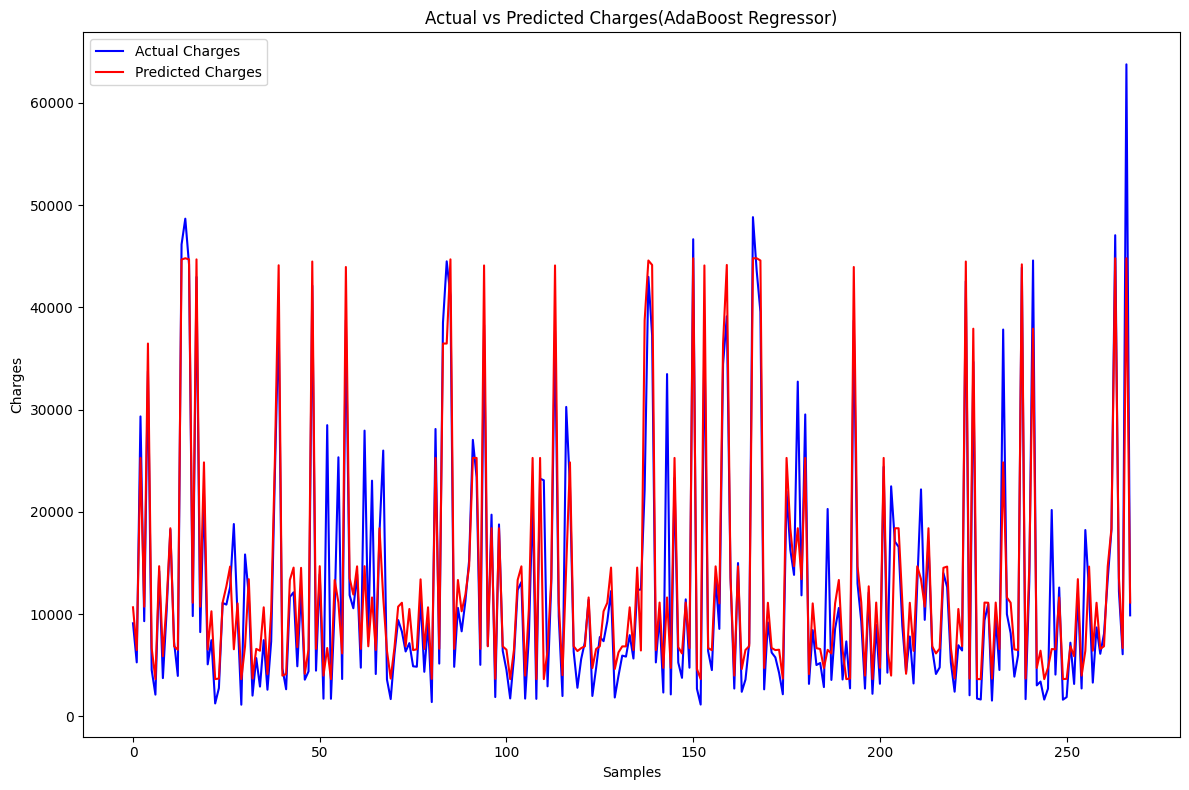

In [17]:
# Plot actual vs predicted
plt.figure(figsize=(12,8))
plt.plot(y_test.values, label='Actual Charges', color='blue')
plt.plot(y_pred, label='Predicted Charges', color='red')
plt.title('Actual vs Predicted Charges(AdaBoost Regressor)')
plt.xlabel('Samples')
plt.ylabel('Charges')
plt.legend()
plt.tight_layout()
plt.show()

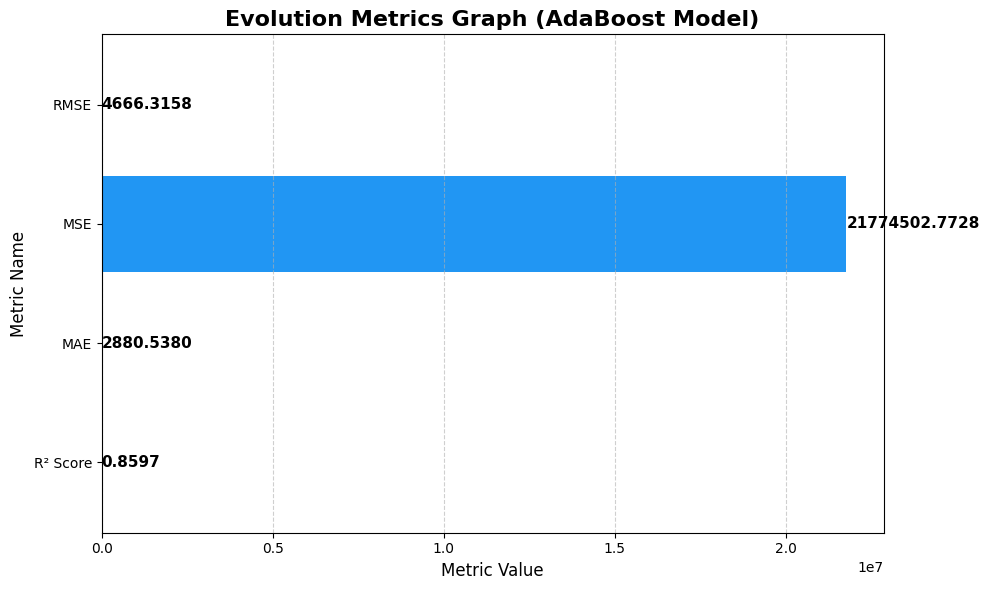

In [18]:
# Define metrics
import matplotlib.pyplot as plt
import seaborn as sns

metrics = {
    'R² Score': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
}

# Create a figure
plt.figure(figsize=(10,6))

# Horizontal bar chart for better readability
plt.barh(list(metrics.keys()), list(metrics.values()), color=['#4CAF50', '#FF9800', '#2196F3'])

# Title and labels
plt.title('Evolution Metrics Graph (AdaBoost Model)', fontsize=16, fontweight='bold')
plt.xlabel('Metric Value', fontsize=12)
plt.ylabel('Metric Name', fontsize=12)

# Add metric values beside bars
for i, (key, value) in enumerate(metrics.items()):
    plt.text(value + 0.01, i, f"{value:.4f}", va='center', fontsize=11, fontweight='bold')

# Grid and style
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

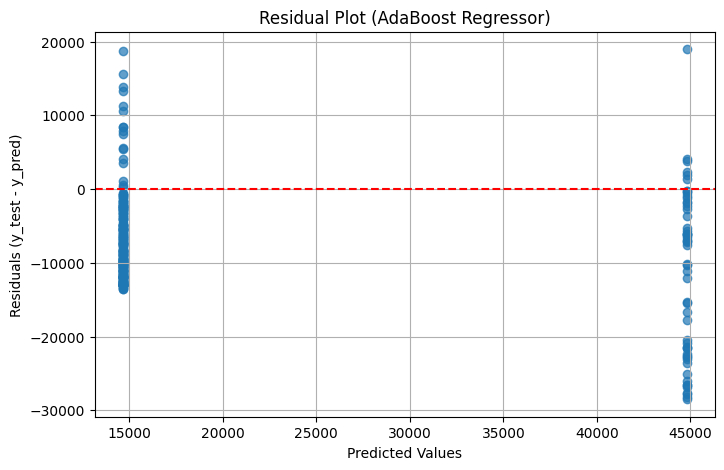

In [19]:
y_pred = adaboost_model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Residual plot (Predicted vs Residuals)
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot (AdaBoost Regressor)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y_test - y_pred)")
plt.grid(True)
plt.show()

In [20]:
joblib.dump({
    "model": adaboost_model,
    "label_encoder": encoders,
    "scaler": scaler
}, "insurance_charges_full_pipeline.pkl")

print("Model saved suucessfully!")

Model saved suucessfully!
